In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from src.resource_estimates.TFIM_simulation import (
    TFIM_phase_estimation_resources,
    TFIM_time_evolution_resources
)

In [2]:
figsz = (14,8)
font = {'size': 12}

matplotlib.rc('font', **font)

J, U = 1,2
alpha = 4
x = 0.01

label_color_map = {
    "2nd order": 'r',
    "4th order": 'g',
    "augmented": 'b',
}

lattice_size_map = {
    "honeycomb": [18,18],
    "square": [31,31],
    "cubic": [15,15,15],
}


lattice_index_map = {
    "honeycomb": 0,
    "square": 1,
    "cubic": 2,
}

def dict_to_t_count(dct: dict) -> int:
    tc = 0
    if "t" in dct.keys():
        tc += dct["t"] 
        
    if "tdg" in dct.keys():
        tc += dct["tdg"] 
        
    if "toffoli" in dct.keys():
        tc += 4*dct["toffoli"]
    return tc

def dict_to_cx_count(dct: dict) -> int:
    cx = 0
    if "cx" in dct.keys():
        cx += dct["cx"] 
    if "toffoli" in dct.keys():
        cx += 6*dct["toffoli"]
    return cx

# Time evolution

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(


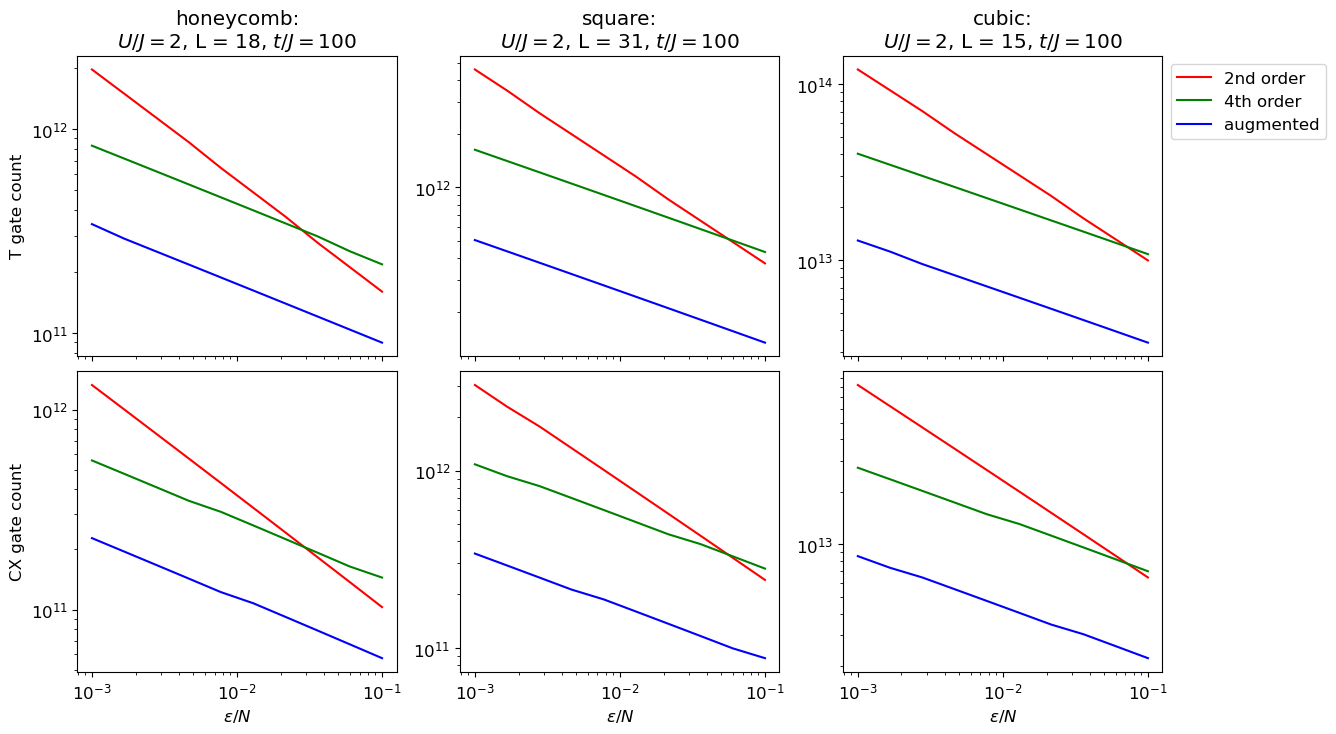

In [3]:
fig, axs = plt.subplots(2,3, figsize = figsz, sharex = 'col')
plt.subplots_adjust(hspace=0.05)
axs[0][0].set_ylabel('T gate count')
axs[1][0].set_ylabel('CX gate count')
for ax in axs[1]:
    ax.set_xlabel(rf'$\varepsilon / N$')

time = 100
logeps = np.linspace(-3, -1, 10)
eps = np.pow(10, logeps)

for lab, i in lattice_index_map.items():
    axs[0][i].set_title(f"{lab}:\n" + rf"$U/J = {U}$, L = {lattice_size_map[lab][0]}, $t/J = {time}$")

for lab, c in label_color_map.items():
    axs[0][2].plot([],[], color = c, label = lab)

for ax1 in axs:
    for ax in ax1:
        ax.set_xscale('log')
        ax.set_yscale('log')

axs[0][2].legend(loc = "upper left", bbox_to_anchor = (1,1))

for lattice, i in lattice_index_map.items():
    for method, c in label_color_map.items():
        dcts = [
            TFIM_time_evolution_resources(
                time,
                e * np.prod(lattice_size_map[lattice]),
                lattice,
                J,
                U,
                method,
                alpha = alpha,
                Ls = lattice_size_map[lattice],
                x=x
            ) for e in eps
        ]
        yt = [dict_to_t_count(dct) for dct in dcts]
        ycx = [dict_to_cx_count(dct) for dct in dcts]
        axs[0][i].plot(eps, yt, color = c)
        axs[1][i].plot(eps, ycx, color = c)

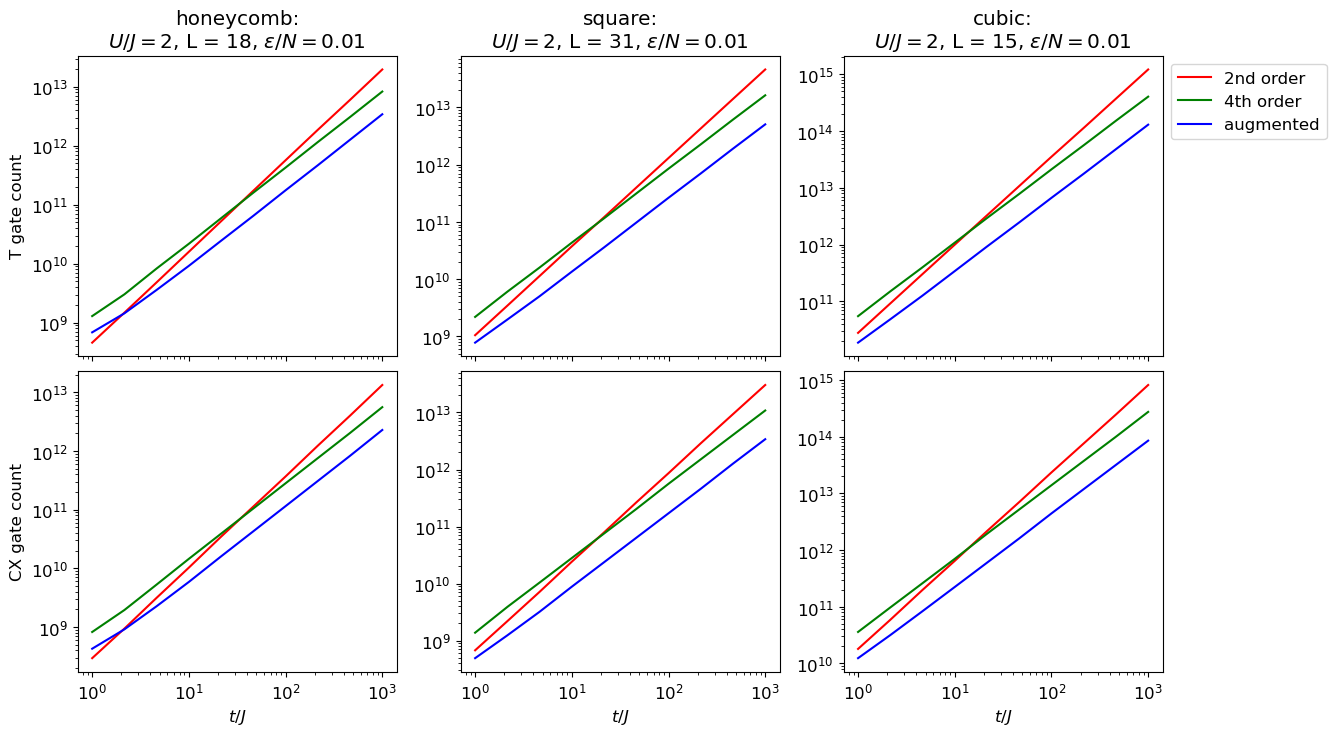

In [4]:
fig, axs = plt.subplots(2,3, figsize = figsz, sharex = 'col')
plt.subplots_adjust(hspace=0.05)
axs[0][0].set_ylabel('T gate count')
axs[1][0].set_ylabel('CX gate count')
for ax in axs[1]:
    ax.set_xlabel(rf'$t/J$')

eps = 0.01
logts = np.linspace(0, 3, 10)
ts = np.pow(10, logts)

for lab, i in lattice_index_map.items():
    axs[0][i].set_title(f"{lab}:\n" + rf"$U/J = {U}$, L = {lattice_size_map[lab][0]}, $\varepsilon / N = {eps}$")

for lab, c in label_color_map.items():
    axs[0][2].plot([],[], color = c, label = lab)

for ax1 in axs:
    for ax in ax1:
        ax.set_xscale('log')
        ax.set_yscale('log')

axs[0][2].legend(loc = "upper left", bbox_to_anchor = (1,1))

for lattice, i in lattice_index_map.items():
    for method, c in label_color_map.items():
        dcts = [
            TFIM_time_evolution_resources(
                t,
                eps * np.prod(lattice_size_map[lattice]),
                lattice,
                J,
                U,
                method,
                alpha = alpha,
                Ls = lattice_size_map[lattice],
                x=x
            ) for t in ts
        ]
        yt = [dict_to_t_count(dct) for dct in dcts]
        ycx = [dict_to_cx_count(dct) for dct in dcts]
        axs[0][i].plot(ts, yt, color = c)
        axs[1][i].plot(ts, ycx, color = c)

# Quantum Phase estimation

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/quantum_phase_estimation.py:134: RuntimeWarning: divide by zero encountered in scalar divide
  return bit_precision_constant/(t*target_error - res)


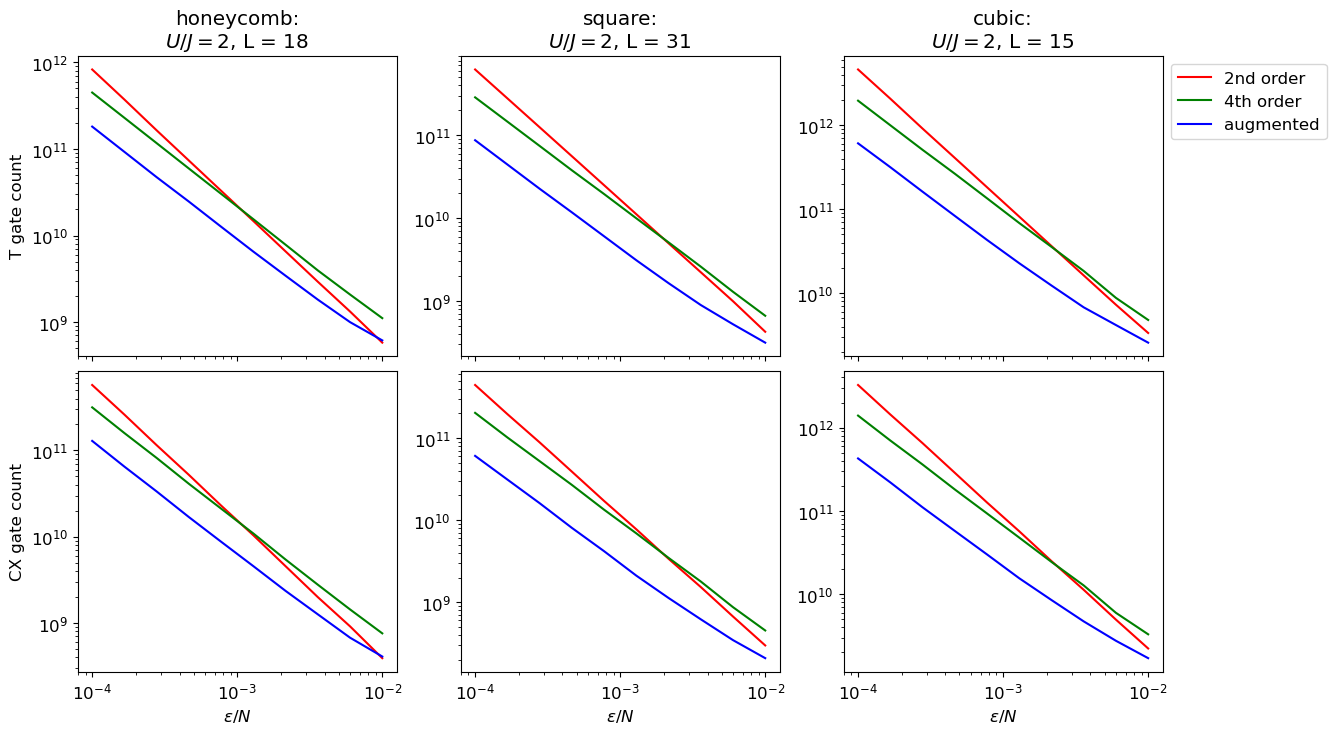

In [5]:
fig, axs = plt.subplots(2,3, figsize = figsz, sharex = 'col')
plt.subplots_adjust(hspace=0.05)
axs[0][0].set_ylabel('T gate count')
axs[1][0].set_ylabel('CX gate count')
for ax in axs[1]:
    ax.set_xlabel(rf'$\varepsilon / N$')

logeps = np.linspace(-4, -2, 10)
eps = np.pow(10, logeps)

for lab, i in lattice_index_map.items():
    axs[0][i].set_title(f"{lab}:\n" + rf"$U/J = {U}$, L = {lattice_size_map[lab][0]}")

for lab, c in label_color_map.items():
    axs[0][2].plot([],[], color = c, label = lab)

for ax1 in axs:
    for ax in ax1:
        ax.set_xscale('log')
        ax.set_yscale('log')

axs[0][2].legend(loc = "upper left", bbox_to_anchor = (1,1))

for lattice, i in lattice_index_map.items():
    for method, c in label_color_map.items():
        dcts = [
            TFIM_phase_estimation_resources(
                e * np.prod(lattice_size_map[lattice]),
                lattice,
                J,
                U,
                method,
                phase_estimation_algorithm="qpe",
                alpha = alpha,
                Ls = lattice_size_map[lattice],
                x=x
            ) for e in eps
        ]
        yt = [dict_to_t_count(dct) for dct in dcts]
        ycx = [dict_to_cx_count(dct) for dct in dcts]
        axs[0][i].plot(eps, yt, color = c)
        axs[1][i].plot(eps, ycx, color = c)

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(
/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/quantum_phase_estimation.py:134: RuntimeWarning: divide by zero encountered in scalar divide
  return bit_precision_constant/(t*target_error - res)


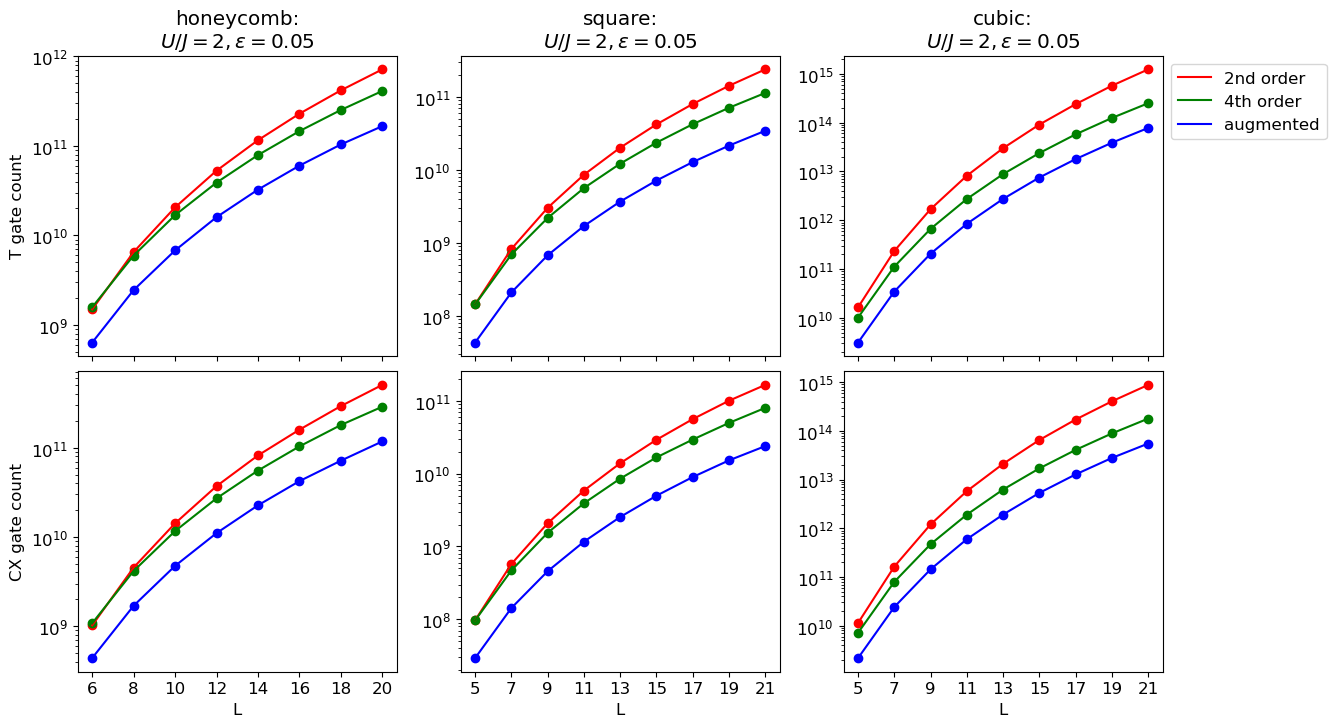

In [8]:
import matplotlib.ticker as ticker

fig, axs = plt.subplots(2,3, figsize = figsz, sharex = 'col')
plt.subplots_adjust(hspace=0.05)
axs[0][0].set_ylabel('T gate count')
axs[1][0].set_ylabel('CX gate count')
for ax in axs[1]:
    ax.set_xlabel('L')

eps = 0.05

lattice_ls_map = {
    "honeycomb": [[L,L] for L in range(6, 22, 2)],
    "square": [[L,L] for L in range(5, 23, 2)],
    "cubic": [[L,L,L] for L in range(5, 23, 2)],
}

for lab, i in lattice_index_map.items():
    axs[0][i].set_title(f"{lab}:\n" + rf"$U/J = {U}, \varepsilon = {eps}$")

for lab, c in label_color_map.items():
    axs[0][2].plot([],[], color = c, label = lab)

for ax1 in axs:
    for ax in ax1:
        #ax.set_xscale('log')
        ax.set_yscale('log')

axs[0][2].legend(loc = "upper left", bbox_to_anchor = (1,1))

for lattice, i in lattice_index_map.items():
    for method, c in label_color_map.items():
        dcts = [
            TFIM_phase_estimation_resources(
                eps,# * np.prod(lattice_size_map[lattice]),
                lattice,
                J,
                U,
                method,
                phase_estimation_algorithm="qpe",
                alpha = alpha,
                Ls = L,
                x=x
            ) for L in lattice_ls_map[lattice]
        ]
        yt = [dict_to_t_count(dct) for dct in dcts]
        ycx = [dict_to_cx_count(dct) for dct in dcts]
        xs = [x[0] for x in lattice_ls_map[lattice]]
        axs[0][i].plot(xs, yt, color = c)
        axs[0][i].scatter(xs, yt, color = c)
        axs[1][i].plot(xs, ycx, color = c)
        axs[1][i].scatter(xs, ycx, color = c)

for lattice, i in lattice_index_map.items():
    axs[1][i].set_xticks([x[0] for x in lattice_ls_map[lattice]])
    axs[1][i].set_xticklabels([x[0] for x in lattice_ls_map[lattice]])
    axs[0][i].xaxis.set_minor_locator(ticker.NullLocator()) # fix weird xticker issue
    axs[1][i].xaxis.set_minor_locator(ticker.NullLocator()) # fix weird xticker issue